<!-- COLAB-BADGE -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB06_ModulesOOP.ipynb)  
[Download .ipynb](https://raw.githubusercontent.com/brendanpshea/computing_concepts_python/main/v2/notebooks/COMP1150_NB06_ModulesOOP.ipynb) · [View on GitHub](https://github.com/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB06_ModulesOOP.ipynb)


# Notebook 6: Modules & Object-Oriented Design
### COMP 1150 — Computer Science Concepts
**Brendan Shea, PhD**

📺 **Lecture video:** *(link coming soon)*

## Learning Outcomes

By the end of this notebook, you will be able to:

- **Import** code from Python's standard library and from your own files, and explain what a **module** and a **namespace** are.
- **Define** a class with `__init__`, create objects from it, and explain the difference between a **class** (the blueprint) and an **object** (a thing built from it).
- **Write** methods that use `self` to act on an object's own data, and explain what `self` refers to.
- **Use** inheritance and `super()` to build a specialized class on top of a general one, and **override** a method.
- **Explain** encapsulation and abstraction, and implement a small **abstract data type** as a class — picking up the ADT idea from Notebook 5.
- **Spot** two classic OOP bugs: forgetting `self.`, and a mutable class attribute shared across every object.

*Maps to course LOs: 6, 8*

## The Problem: Too Much Copy-Paste

Merlin runs **Merlin Advisory**, a small consulting shop just off the main square in Camelot. His team has a habit: every time they start a new client report, somebody copies the last report's code, pastes it into a fresh file, and changes the numbers. By the third month there are nine slightly different copies of the same "calculate the fee" code, and three of them have different bugs.

Down the street, **Guinevere** at **Camelot Civic Systems** has the opposite problem. She isn't repeating code — she's drowning in *loose variables*. Every citizen in her system is tracked by a tangle of separate lists: `names`, `ages`, `wards`, `balances`. To update one person she has to touch four lists and pray the positions still line up.

Two problems, two fixes — and they're the two halves of this notebook.

- **Modules** solve Merlin's problem. Write code *once*, in one file, and **import** it everywhere. Fix a bug in one place; it's fixed everywhere.
- **Objects** solve Guinevere's problem. Instead of four lists that have to stay in sync, bundle each citizen's data — *and the things you can do to it* — into one tidy package called an **object**.

Object-oriented design (OOP) is the second idea taken seriously: programs built out of objects that each know their own data and their own behavior. By the end you'll build classes for a security firm, a research lab, and a delivery service — and you'll see why Guinevere sleeps better at night.

### The Roadmap

1. **Modules & imports** — borrow code from Python, and split your own code into reusable files.
2. **Classes & objects** — the blueprint and the things you stamp out from it.
3. **Methods & `self`** — giving objects something to *do*.
4. **Inheritance** — build a general class once, then specialize it.
5. **Abstraction** — hide the storage behind a clean interface (the Notebook 5 ADT idea, now in code).

A quick reminder before we start: in Notebook 4 you learned to write **functions** — reusable blocks of behavior. Everything here builds on that. A method is just a function that lives inside an object.

## Modules: Code You Don't Have to Rewrite

A **module** is just a file of Python code that you can pull into another file. Python ships with hundreds of them — together they're called the **standard library** — covering math, dates, randomness, files, and more. You don't install anything; you just `import` what you need.

Think of it as Merlin borrowing a colleague's finished work instead of redoing it. The `import` statement is how you say "I'd like to use the tools in that file, please."

Merlin needs a square root for a risk calculation. Square roots aren't built into plain Python — they live in the **`math`** module.

**Importing a whole module.** You name the module, then reach inside it with a dot:

```python
import module_name        # bring the whole module into reach
module_name.tool(...)     # use something from inside it — the dot means "look inside"
```

The next cell imports `math` and uses it.

In [1]:
import math

risk_score = math.sqrt(144)
print("Risk score:", risk_score)
print("Pi, for good measure:", math.pi)

Risk score: 12.0
Pi, for good measure: 3.141592653589793


### Understanding the Code

- `import math` brings the whole `math` module into reach.
- `math.sqrt(144)` reads as "the `sqrt` tool *that lives inside* `math`." The dot means "look inside."
- `math.pi` isn't a function — it's a value the module hands you. Modules can offer both.

Writing `math.` in front of everything gets tiring. The `from ... import ...` form lets you pull *specific* names out of a module and use them bare.

**Importing specific names.** Reach into a module and pull out just the names you want:

```python
from module_name import tool   # grab only `tool` out of the module
tool(...)                      # now call it directly — no module_name. prefix
```

Merlin's assistant wants a random client to spot-check and today's date for the report header.

In [2]:
from random import choice
from datetime import date

clients = ["Pellinore Estates", "Astolat Mills", "Lyonesse Foods"]
print("Audit this one today:", choice(clients))
print("Report date:", date.today())

Audit this one today: Astolat Mills
Report date: 2026-06-02


### Understanding the Code

- `from random import choice` reaches *into* `random` and pulls out just `choice`. Now you call `choice(...)` directly — no `random.` prefix.
- `choice(clients)` picks one item from the list at random.
- `from datetime import date` does the same for the `date` tool; `date.today()` returns today's date.
- The trade-off: `from` imports are shorter to type, but `import math` keeps it obvious *where* a name came from.

The real payoff is writing your **own** module. The cell below uses Jupyter's `%%writefile` to save a small file, `camelot_tools.py`, holding one function. In a normal project you'd just create that file in your editor.

In [3]:
%%writefile camelot_tools.py

def advisory_fee(hours, rate=150):
    """Merlin's fee: hours x rate, plus a 10% surcharge over 40 hours."""
    base = hours * rate
    if hours > 40:
        base = base * 1.10
    return round(base, 2)

Writing camelot_tools.py


Now any file — including this notebook — can `import` that function. Merlin writes the fee rule **once**; every report shares the same copy. Fix it here, and it's fixed for the whole firm.

In [4]:
from camelot_tools import advisory_fee

print("Small job:", advisory_fee(10))
print("Big job:", advisory_fee(50))

Small job: 1500
Big job: 8250.0


### Understanding the Code

- `%%writefile camelot_tools.py` saved everything below it as a real file named `camelot_tools.py`.
- `from camelot_tools import advisory_fee` imports *your* function exactly like importing from the standard library — Python doesn't care that you wrote it.
- That's the cure for copy-paste: **one definition, many imports.** No more nine drifting copies.

### ✏️ Your Turn — Your Own Toolkit

Python's standard library is full of ready-made tools. Import one you haven't used yet and try it — for example `import statistics` then `statistics.mean([...])`, or `from datetime import date` then `date.today()`. Print the result.

In [ ]:
#| eval: false
# TODO: import a tool from the standard library and use it.
# import statistics
# print(statistics.mean([10, 20, 30]))

## What OOP Is: A Way of Thinking, Not Just Syntax

Before we build a single class, step back. The code you wrote in Notebooks 1–5 all followed one style — what computer scientists call a **paradigm**, a basic way of organizing a program. That style was **procedural**: data sits in variables, and functions reach out, grab the data, do something to it, and put it back. The data is passive. The functions are in charge.

**Object-oriented programming (OOP)** turns that around. Instead of passive data and bossy functions, you build **objects** that own their data *and* the behavior that goes with it. A `Citizen` object won't wait for some far-away function to change its balance — it has its own `pay` method and changes its own balance. Data and behavior travel together.

Why care? In Guinevere's old setup, the rule "how do I update a citizen?" lived somewhere far from the citizen's data, easy to get out of sync. In OOP, that rule lives *with* the citizen. Big programs stay sane because each object minds its own business.

This idea isn't new. It runs back to the **Simula** language in the 1960s and **Smalltalk** in the 1970s, where Alan Kay pictured objects as little machines sending each other messages. (Whether OOP was a *good* idea is a real debate — that's the subject of this notebook's case study. Here we focus on learning to *think and design* in objects.)

The contrast is below: procedural code keeps data and functions in separate piles; object-oriented code bundles each thing's data and behavior into one object.

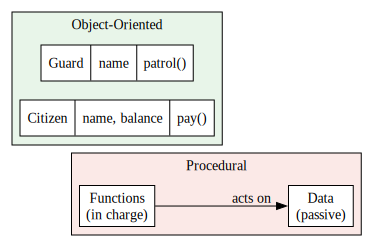

In [5]:
#| echo: false
#@title 🧭 Two paradigms — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr(rankdir="LR")
with g.subgraph(name="cluster_proc") as s:
    s.attr(label="Procedural", style="filled", fillcolor="#fbe9e7")
    s.node("data", "Data\n(passive)", shape="box", style="filled", fillcolor="white")
    s.node("func", "Functions\n(in charge)", shape="box", style="filled", fillcolor="white")
    s.edge("func", "data", label="acts on")
with g.subgraph(name="cluster_oo") as s:
    s.attr(label="Object-Oriented", style="filled", fillcolor="#e8f5e9")
    s.node("o1", "{Citizen|name, balance|pay()}", shape="record", style="filled", fillcolor="white")
    s.node("o2", "{Guard|name|patrol()}", shape="record", style="filled", fillcolor="white")
g

### 💭 Think About It — Seeing the World as Objects

OOP is a way of thinking: model a problem as objects that bundle data together with the things they can do.

- Look around the room and pick one thing. Describe it as an "object": what does it *know* (its data) and what can it *do* (its actions)?
- Bundling data with behavior is just one way to organize a program — the earlier notebooks used separate functions and variables. What might be appealing about keeping related data and actions together?
- Some people say OOP matches how humans naturally think about the world. Do you agree? Is "everything is an object" always a helpful lens, or can it be forced?

There are no single right answers here — share a sentence or two on each.

**Reading it:** On the left, data and functions are separate boxes — the functions reach over to act on the data. On the right, each object carries its own data *and* its own methods in one bundle. That bundling is the whole idea of OOP.

## Classes & Objects: Blueprints and the Things You Build From Them

Modules organize *code*. Now we organize *data*. Back to Guinevere's tangle of parallel lists — let's first see exactly how bad it gets, so the fix feels earned.

The cell below tracks two citizens the "loose variables" way: separate lists, lined up by position.

In [6]:
names    = ["Elaine Astolat", "Percival Wales"]
ages     = [34, 41]
wards    = ["North", "Harbor"]
balances = [120.00, 0.00]

# To raise Elaine's balance, you must remember she's at index 0 in EVERY list:
balances[0] = balances[0] + 25
print(names[0], "owes", balances[0], "in", wards[0], "ward")

Elaine Astolat owes 145.0 in North ward


See the problem? Elaine's facts are scattered across four lists, held together only by the fragile promise that index `0` means "Elaine" in all of them. Sort one list, or insert a citizen in the middle, and everything silently misaligns. There has to be a better way — and there is.

A **class** is a blueprint. It describes what *every* citizen has. From one blueprint you stamp out as many **objects** as you like, and each object keeps all of its own facts together in one place.

**Defining a class and building an object.** Use the `class` keyword and a special `__init__` setup method; `self` stands for the object being built:

```python
class ClassName:
    def __init__(self, value):    # runs automatically when you build one
        self.attribute = value    # store a fact ON the object itself

thing = ClassName("some value")   # build an object — __init__ runs right now
thing.attribute                   # read a fact back with a dot
```

Guinevere defines a `Citizen` class once.

In [7]:
class Citizen:
    def __init__(self, name, ward, balance):
        self.name = name
        self.ward = ward
        self.balance = balance

elaine = Citizen("Elaine Astolat", "North", 120.00)
print(elaine.name, "is in", elaine.ward, "ward")

Elaine Astolat is in North ward


### Understanding the Code

- `class Citizen:` starts the blueprint. By convention class names use `CapWords`.
- `__init__` is a special method that runs **automatically** every time you create a Citizen — it's the setup routine. You never call it by name.
- `self.name = name` stores the value *on the object itself*, so it travels with that citizen forever.
- `elaine = Citizen("Elaine Astolat", "North", 120.00)` builds one object. Those three arguments line up with `__init__`'s parameters (after `self`).
- `elaine.name` reads a fact back. One object, all its facts in one bundle — no parallel lists.

A class earns its keep when you make *many* objects from it. Each call to `Citizen(...)` produces a brand-new, independent object with its own data.

In [8]:
percival = Citizen("Percival Wales", "Harbor", 0.00)
roster = [elaine, percival]

for person in roster:
    print(person.name, "—", person.ward, "ward, balance", person.balance)

Elaine Astolat — North ward, balance 120.0
Percival Wales — Harbor ward, balance 0.0


### Understanding the Code

- `percival` is a second object built from the same blueprint, with its own values.
- A list of objects (`roster`) replaces Guinevere's four parallel lists with **one** list where each entry carries everything about one person.
- Looping over objects and reading `person.name`, `person.ward` is far safer than juggling matched indexes.

### 🔮 Predict Before You Run

`elaine` and `percival` were built from the same class. Before running the next cell, predict: if we change **elaine's** balance, does percival's balance change too?

In [9]:
elaine.balance = elaine.balance + 50
print("Elaine:", elaine.balance)
print("Percival:", percival.balance)

Elaine: 170.0
Percival: 0.0


### Understanding the Code

- Changing `elaine.balance` touched **only** elaine. Percival is untouched.
- Each object has its **own** copy of the data set up in `__init__`. The class is the shared blueprint; the objects are independent.
- This is the opposite of the aliasing trap from Notebook 5 — separate objects don't share their instance data.

## Methods: Giving Objects Something to Do

So far our objects just *hold* data. The real power of OOP is bundling data **with the behavior that acts on it**. A function that lives inside a class is called a **method**.

Here's the idea everyone trips over first, so we'll go slow: every method's first parameter is `self`, and `self` means *"the particular object this method was called on."*

Guinevere adds a `pay` method to `Citizen` so a citizen can reduce their own balance.

**Defining a method.** A method is a function written inside the class, and its first parameter is always `self`:

```python
class ClassName:
    def method_name(self, argument):   # self first, then the real arguments
        self.attribute = argument      # act on THIS object's own data

thing.method_name(value)               # you pass `value`; Python fills in `self`
```

Watch the `self` in the cell below.

In [10]:
class Citizen:
    def __init__(self, name, ward, balance):
        self.name = name
        self.ward = ward
        self.balance = balance

    def pay(self, amount):
        self.balance = self.balance - amount
        return self.balance

elaine = Citizen("Elaine Astolat", "North", 120.00)
print("After paying 20:", elaine.pay(20))

After paying 20: 100.0


### Understanding the Code

- `def pay(self, amount):` — `self` is first, `amount` is the real argument.
- When you write `elaine.pay(20)`, Python quietly fills `self` with `elaine` and `amount` with `20`. **You don't pass `self` yourself** — that's why the call has one argument but the definition lists two.
- Inside the method, `self.balance` means "*this object's* balance." For this call, that's elaine's balance.

Why does `self` matter so much? Because the **same method** does different things depending on **which object** you call it on. `self` is how the method knows whose data to touch.

In [11]:
percival = Citizen("Percival Wales", "Harbor", 300.00)

elaine.pay(20)      # self = elaine
percival.pay(75)    # self = percival
print("Elaine:", elaine.balance)
print("Percival:", percival.balance)

Elaine: 80.0
Percival: 225.0


### Understanding the Code

- One method definition, two objects, two different results.
- In the first call `self` *is* elaine; in the second, `self` *is* percival. The code is identical — the object differs.
- That's the whole trick: methods are written once, but each object brings its own `self`.

### A Trap: Forgetting `self.`

Inside a method, you must write `self.balance`, not bare `balance`, to touch the object's data. A bare name just makes a throwaway local variable that vanishes when the method ends. The next cell shows the bug.

In [12]:
class BrokenCitizen:
    def __init__(self, name, balance):
        self.name = name
        self.balance = balance

    def pay(self, amount):
        balance = self.balance - amount   # BUG: missing self. (writes a local)
        return "done"

p = BrokenCitizen("Test", 100)
p.pay(40)
print("Balance after paying 40:", p.balance)   # still 100 — the payment vanished

Balance after paying 40: 100


### Understanding the Code

- `balance = self.balance - amount` created a *local* variable called `balance` and threw it away when `pay` returned.
- The object's real `self.balance` was never touched — so it's still `100`.
- The fix is one word: `self.balance = self.balance - amount`. Missing `self.` is the single most common beginner OOP bug. When an update "doesn't stick," check for it first.

### ✏️ Your Turn — Lancelot's Athlete Class

Write a class `Athlete` with an `__init__` that stores `name` and `wins` (default `0`), plus a method `record_win(self)` that adds one to `wins`. Make **two** athletes, record a few wins for each, print both — and confirm that recording a win for one does **not** change the other's total.

In [ ]:
#| eval: false
# TODO: define class Athlete with __init__(self, name, wins=0)
#       and a method record_win(self) that does self.wins += 1.

# class Athlete:
#     ...

# Make two athletes, record some wins, then print both totals.

Some data isn't meant to be poked at from outside. Python has no hard "private" lock, but there's a strong convention: a leading underscore (`_pin`) means *"internal — please don't touch directly."* This is **encapsulation**: the object guards its own data and exposes safe methods instead. We'll also add `__str__`, a special method that controls how the object prints.

**The underscore convention and a `__str__` method.**

```python
class ClassName:
    def __init__(self, value):
        self._hidden = value         # leading _ : "internal — don't touch from outside"

    def __str__(self):               # special method: controls what print() shows
        return f"ClassName(...)"     # return the text you want printed
```

In [13]:
class Account:
    def __init__(self, owner, pin):
        self.owner = owner
        self._pin = pin          # leading _ : internal, don't touch from outside

    def check_pin(self, guess):
        return guess == self._pin

    def __str__(self):
        return f"Account({self.owner})"   # note: no PIN leaked

a = Account("Guinevere", 4821)
print(a)                     # uses __str__
print(a.check_pin(4821))     # the safe, public way to test the PIN

Account(Guinevere)
True


### Understanding the Code

- `self._pin` still works exactly like any attribute — the underscore is a *message to humans*, not a lock. It says "this is internal."
- Other code is meant to call `check_pin(...)` rather than read `_pin` directly. The object controls access — that's **encapsulation**.
- `__str__` runs whenever the object is printed, giving a clean, readable result instead of `<__main__.Account object at 0x...>` — and notice it deliberately doesn't print the PIN.

### ✏️ Your Turn — Guinevere's `__str__`

Guinevere wants her `Citizen` objects to print nicely instead of as `<...object at 0x...>`. Add a `__str__` method to `Citizen` that returns something like `"Elaine Astolat (North ward): owes 120.0"`. Then create a citizen and `print` it to confirm your `__str__` runs.

In [ ]:
#| eval: false
class Citizen:
    def __init__(self, name, ward, balance):
        self.name = name
        self.ward = ward
        self.balance = balance

    # TODO: add __str__(self) returning e.g.
    #       "Elaine Astolat (North ward): owes 120.0"

# c = Citizen("Elaine Astolat", "North", 120.0)
# print(c)

## Inheritance: Build Once, Specialize Later

**Arthur Pendragon** runs **Pendragon Security**. He has plain *guards* and elite *knights*. Both have a name and clock in for patrol — but knights also carry a rank and lead a squad. He could write two totally separate classes and duplicate the shared parts... but duplication is exactly what we're trying to kill.

**Inheritance** lets a class build *on top of* another. The general class is the **parent** (or base); the specialized one is the **child** (or subclass). The child gets everything the parent has, for free, plus its own extras.

First the parent. A `Guard` has a name and can report for patrol.

In [14]:
class Guard:
    def __init__(self, name):
        self.name = name

    def patrol(self):
        return f"{self.name} is on patrol."

gareth = Guard("Gareth")
print(gareth.patrol())

Gareth is on patrol.


### Understanding the Code

- Nothing new yet — `Guard` is an ordinary class with one attribute and one method.
- The point is what comes next: we won't rewrite any of this for knights.

Now the child. `class Knight(Guard):` means "a Knight **is a** Guard, with more." Even with an empty body, a Knight already has `name` and `patrol` — inherited from Guard.

**Inheriting from a parent.** Put the parent class in parentheses after the child's name:

```python
class Child(Parent):   # Child gets all of Parent's attributes and methods for free
    ...
```

In [15]:
class Knight(Guard):
    pass   # empty body — but Knight already inherits everything from Guard

lancelot = Knight("Lancelot")
print(lancelot.patrol())   # works, even though we never defined patrol in Knight

Lancelot is on patrol.


### Understanding the Code

- `Knight(Guard)` puts `Guard` in parentheses — that's the inheritance link.
- `pass` means "no extra code," yet `lancelot.patrol()` still works. Knight **inherited** `__init__` and `patrol`.
- This is the anti-duplication payoff: shared behavior is written once, in the parent.

Knights need *more* than guards: a rank. So Knight gets its own `__init__`. But we don't want to retype the name-setup — we ask the parent to do its part with **`super().__init__()`**, then add the new piece.

**Reusing the parent's setup.** `super()` refers to the parent class; call its `__init__` first, then add what's new:

```python
class Child(Parent):
    def __init__(self, a, b):
        super().__init__(a)   # let Parent run its own setup for the shared part
        self.b = b            # then add the data unique to Child
```

In [16]:
class Knight(Guard):
    def __init__(self, name, rank):
        super().__init__(name)   # let Guard set up self.name
        self.rank = rank         # then add what's new to Knight

lancelot = Knight("Lancelot", "First Knight")
print(lancelot.patrol())
print("Rank:", lancelot.rank)

Lancelot is on patrol.
Rank: First Knight


### Understanding the Code

- `super()` means "the parent class, `Guard`." `super().__init__(name)` runs Guard's setup, so `self.name` is handled by the code that already exists.
- `self.rank = rank` adds the part that's unique to knights.
- Two ideas share one keyword: inheritance *gives* you the parent's methods; `super()` lets you *reuse* the parent's setup instead of copying it.

A child can also **override** a method — define one with the same name as the parent's, and the child's version wins for child objects. Knights announce their rank on patrol; guards don't.

In [17]:
class Knight(Guard):
    def __init__(self, name, rank):
        super().__init__(name)
        self.rank = rank

    def patrol(self):   # same name as Guard.patrol — this version wins for Knights
        return f"{self.rank} {self.name} leads the patrol."

print(Guard("Gareth").patrol())
print(Knight("Lancelot", "First Knight").patrol())

Gareth is on patrol.
First Knight Lancelot leads the patrol.


### Understanding the Code

- Both classes have a `patrol` method. Python uses the one belonging to the object's *own* class — Guard's for guards, Knight's for knights.
- The Knight version **overrides** the inherited one. The Guard version is untouched and still used by guards.
- Same method name, different behavior per class — this is how one line of calling code (`x.patrol()`) adapts to whatever object `x` is.

### ✏️ Your Turn — Morgan's Researcher Hierarchy

Write a base class `Researcher` that stores `name` and has a method `describe()` returning `"<name> runs experiments."`. Then write a subclass `LeadResearcher(Researcher)` that adds a `team_size` (using `super().__init__()`) and **overrides** `describe()` to also mention the team size. Make one of each and print both descriptions.

In [ ]:
#| eval: false
# TODO: class Researcher with __init__(self, name) and describe(self).
# TODO: class LeadResearcher(Researcher) that adds team_size via super().__init__()
#       and overrides describe().

# r    = Researcher("Morgan")
# lead = LeadResearcher("Nimue", team_size=4)
# print(r.describe())
# print(lead.describe())

### Polymorphism: One Call, Many Behaviors

Look again at what just happened. We called `.patrol()` on a guard and on a knight, and each did the *right thing for its own type* — and we never checked which was which. That ability has a name: **polymorphism** (Greek for "many shapes"). One method name, many behaviors, chosen automatically by the object.

It pays off when you have a *mix* of objects. Arthur's roster holds guards and knights together. He loops once and calls `.patrol()` on each — Python runs the correct version every time. The next cell builds a mixed roster and patrols it.

In [18]:
roster = [Guard("Gareth"), Knight("Lancelot", "First Knight"), Guard("Kay")]

for officer in roster:
    print(officer.patrol())   # each object runs its OWN patrol()

Gareth is on patrol.
First Knight Lancelot leads the patrol.
Kay is on patrol.


### Understanding the Code

- The list mixes two different classes, yet the loop treats every item the same way.
- Each `officer.patrol()` runs the version belonging to *that* object's class — Guard's for guards, Knight's for knights.
- We never wrote an `if` to check the type. That's the power of **polymorphism**: add a brand-new kind of officer tomorrow, and this loop keeps working untouched.

### Picture It: The Class Family Tree

The diagram below shows the relationship: `Knight` inherits from `Guard`, adding `rank` and its own `patrol`. The next cell draws it.

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
C:\Users\brend\AppData\Local\Temp\claude\ipykernel_75116\1007185676.py:8: SyntaxWarning: invalid escape sequence '\l'
  g.node("Knight", "{Knight|name (inherited)\lrank (new)|patrol() (overridden)\l}")


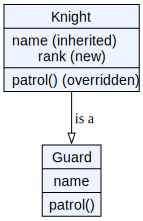

In [19]:
#| echo: false
#@title 🌳 Class family tree — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr("node", shape="record", style="filled", fillcolor="#eef4ff", fontname="Helvetica")
g.node("Guard",  "{Guard|name|patrol()}")
g.node("Knight", "{Knight|name (inherited)\lrank (new)|patrol() (overridden)\l}")
g.edge("Knight", "Guard", label="  is a", arrowhead="onormal")
g

**Reading it:** The hollow arrow points from child to parent and reads "Knight *is a* Guard." Knight keeps `name` from Guard, adds `rank`, and replaces `patrol` with its own version.

### A Trap: A Shared Mutable Class Attribute

If you put a **mutable** value (like a list) directly in the class body instead of inside `__init__`, *every* object shares the one same list. Change it through one object and it changes for all of them. The next cell shows the surprise.

In [20]:
class Squad:
    members = []          # BUG: one list shared by ALL squads

    def add(self, name):
        self.members.append(name)

red = Squad()
blue = Squad()
red.add("Gareth")
print("Red squad:", red.members)
print("Blue squad:", blue.members)   # Gareth leaked into Blue!

Red squad: ['Gareth']
Blue squad: ['Gareth']


### Understanding the Code

- `members = []` sits in the *class body*, so there is exactly one list, owned by the class and shared by every object.
- Adding to `red.members` changed the one shared list, so `blue.members` shows it too.
- **The fix:** create the list per-object inside `__init__` (`self.members = []`). Anything that should differ between objects belongs in `__init__`, not the class body. This is the OOP cousin of Notebook 5's aliasing trap.

## "Is-a" vs. "Has-a": Inheritance Isn't Always the Answer

Inheritance is powerful, and beginners reach for it too often. There's a simple test. Ask: is this *a kind of* that, or does this *contain* that?

- **Is-a → inheritance.** A Knight *is a* kind of Guard, so `Knight(Guard)` is right.
- **Has-a → composition.** A Squad is *not* a kind of guard — a Squad *has* guards. You don't inherit; you store them inside.

That second pattern — building an object out of other objects — is called **composition**. Arthur's `Squad` below *has a* list of guards and delegates the work to them.

In [21]:
class Squad:
    def __init__(self, name):
        self.name = name
        self.members = []          # a Squad HAS guards (composition)

    def recruit(self, guard):
        self.members.append(guard)

    def patrol_all(self):
        return [g.patrol() for g in self.members]

watch = Squad("Night Watch")
watch.recruit(Guard("Gareth"))
watch.recruit(Knight("Lancelot", "First Knight"))
print(watch.patrol_all())

['Gareth is on patrol.', 'First Knight Lancelot leads the patrol.']


### Understanding the Code

- `Squad` does **not** inherit from `Guard` — a squad isn't a guard. It *holds* guards in `self.members`. That's **composition**.
- `patrol_all` does its job by asking each member to `patrol()` — the Squad delegates to the objects it contains.
- A famous design guideline says **"favor composition over inheritance."** Composition is more flexible: you can change a squad's members while the program runs, but you can't change a class's parent. Overusing inheritance is one of the main complaints in this notebook's case study.

### 💭 Think About It — Drawing the Family Tree

Inheritance models an "is-a" relationship (a dog *is an* animal); composition models "has-a" (a car *has an* engine). Choosing wrong leads to awkward designs.

- Real-world categories are messy: is a tomato a fruit or a vegetable? Why might forcing the world into clean "is-a" hierarchies cause trouble for a programmer?
- Give an everyday example of an "is-a" relationship and a "has-a" relationship. How did you decide which was which?
- "Prefer composition over inheritance" is common advice. Without the jargon, why might building things by *combining parts* be more flexible than building them by *specializing a parent*?

There are no single right answers here — share a sentence or two on each.

## Designing with Objects: Finding the Classes

Knowing the syntax is not the same as knowing *what classes to build*. Deciding that is **design** — and it's the part that makes OOP a computer-science skill, not just a Python trick. So where do classes come from?

A reliable way to start is the **noun/verb heuristic**. Write the problem in plain English, then:

- **Nouns** (the things) become candidate **classes** and **attributes**.
- **Verbs** (the actions) become candidate **methods**.

It won't hand you a perfect design, but it gets you off the blank page.

Here is Nimue describing Lake Logistics in plain words:

> "A **dispatch desk** holds **packages** waiting to go out. Each **package** has a **destination** and a **weight**. A **courier** *picks up* the next package and *delivers* it."

Underline the nouns and verbs and the design almost writes itself:

- Nouns → classes: `DispatchDesk`, `Package`, `Courier`. Attributes: a package's `destination` and `weight`.
- Verbs → methods: `pick_up`, `deliver`.

One more pair of ideas tells you whether you carved the classes *well*.

### Two Words for Judging a Design: Cohesion and Coupling

Designers judge a set of classes with two ideas worth knowing by name:

- **Cohesion** — how focused one class is. A `Package` that only knows package things has *high* cohesion. A class that tracks packages *and* couriers *and* billing *and* the weather is doing too much — low cohesion. **Each class should have one clear responsibility.**
- **Coupling** — how tangled classes are with each other. If changing `Package` forces you to rewrite `Courier`, they are *tightly* coupled, and fragile. Good designs keep coupling *low*, so you can change one class without breaking the others.

The goal in one line: **high cohesion, low coupling.** Each object minds one job and talks to the others only through clean methods — exactly the interfaces you have been building.

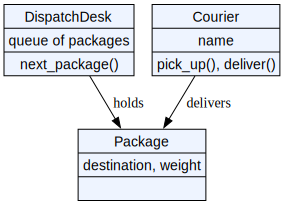

In [22]:
#| echo: false
#@title 🧩 Noun/verb design — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr("node", shape="record", style="filled", fillcolor="#eef4ff", fontname="Helvetica")
g.node("desk", "{DispatchDesk|queue of packages|next_package()}")
g.node("pkg",  "{Package|destination, weight|}")
g.node("cour", "{Courier|name|pick_up(), deliver()}")
g.edge("desk", "pkg", label="  holds")
g.edge("cour", "pkg", label="  delivers")
g

**Reading it:** Each box is one class with high cohesion — it owns just its own data and jobs. The arrows are the only links between them (low coupling): a Courier touches a Package only by delivering it, never by reaching inside the DispatchDesk. Change one box and the others barely notice.

### ✏️ Your Turn — Morgan's Lab, On Paper

**No code for this one — design first.** Morgan le Fay describes Avalon Health Sciences:

> "A **study** has a **title** and a list of **participants**. Each **participant** has an **ID** and an **age**. A **researcher** can *enroll* a participant and *count* how many are signed up."

Using the **noun/verb heuristic**, in a markdown cell list (a) the **classes** you'd create, (b) the **attributes** each holds, and (c) the **methods**. Then write one sentence on which class should own the `enroll` method, and why. (Hint: think about cohesion — which class is *responsible* for the participant list?)

## Abstraction: One Interface, Many Implementations

In Notebook 5 we met **abstract data types (ADTs)**: the idea that a collection's *promise* (what it does) is separate from its *storage* (how it does it). We even used a `CustomerQueue` without caring how it stored things. Now we build one on purpose — that's what classes are *for*.

**Nimue** runs **Lake Logistics**. Her dispatch desk needs a **queue**: packages are handled first-come, first-served. The promise is simple: *add a package to the back; take the next one from the front.* How it's stored is her business, not her users' business.

### Abstraction: The Big Idea Behind All of Computer Science

Abstraction sounds like a fancy word, but you have leaned on it all semester. **Abstraction means hiding complicated details behind a simple surface, so you can use a thing without knowing how it works inside.**

Trace it through the whole course. The transistors from Notebook 2 hide under **logic gates**. Logic gates hide under the CPU's **machine code**. Machine code hides under **Python**. And now your **classes** hide their own details under a few method names. Each layer lets the layer above it ignore the mess below.

That is not a minor convenience — it is *the* reason software can grow large at all. No human can hold a whole system in mind at the transistor level. Abstraction is how a small mind builds a large machine, one layer resting on the next. A well-designed class is just one more layer in that tower — which is exactly what Nimue's delivery queue, below, will be.

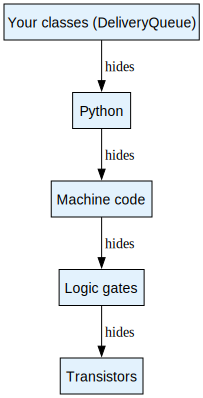

In [23]:
#| echo: false
#@title 🏛️ Abstraction layers — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr("node", shape="box", style="filled", fillcolor="#e3f2fd", fontname="Helvetica")
layers = ["Your classes (DeliveryQueue)", "Python", "Machine code", "Logic gates", "Transistors"]
for name in layers:
    g.node(name, name)
for upper, lower in zip(layers, layers[1:]):
    g.edge(upper, lower, label="  hides")
g

**Reading it:** Read top to bottom. Each layer rests on the one beneath it and hides that layer's detail. You write `DeliveryQueue` without ever thinking about transistors — every layer below is abstracted away.

The `DeliveryQueue` class below stores packages in a list, but hides that behind two methods: `enqueue` and `dequeue`. Code that uses the queue never touches the list directly.

In [24]:
class DeliveryQueue:
    def __init__(self):
        self._items = []           # storage — hidden behind the methods

    def enqueue(self, package):    # add to the back
        self._items.append(package)

    def dequeue(self):             # take from the front
        return self._items.pop(0)

    def is_empty(self):
        return len(self._items) == 0

Nimue's dispatcher uses the queue through its **interface** only — `enqueue`, `dequeue`, `is_empty`. They never see the list inside.

In [25]:
dispatch = DeliveryQueue()
dispatch.enqueue("Camelot #1")
dispatch.enqueue("Astolat #2")
dispatch.enqueue("Lyonesse #3")

while not dispatch.is_empty():
    print("Now delivering:", dispatch.dequeue())

Now delivering: Camelot #1
Now delivering: Astolat #2
Now delivering: Lyonesse #3


### Understanding the Code

- `enqueue` adds to the back; `dequeue` removes from the front — first in, first out.
- The dispatcher's loop talks only to the **interface** (the method names). It has no idea a Python list is doing the work.
- That's **abstraction**: Nimue could swap the list for something faster tomorrow, and as long as the four method names behave the same, the dispatcher code doesn't change at all.

### Picture It: One Interface, Two Implementations

The diagram makes the point: two completely different storage choices can sit behind the *same* promise. Callers only ever see the top box.

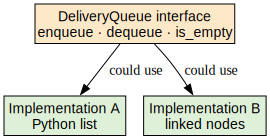

In [26]:
#| echo: false
#@title 🔌 Interface vs. implementation — diagram code (click to show)
from graphviz import Digraph

g = Digraph()
g.attr("node", shape="box", style="filled", fontname="Helvetica")
g.node("api", "DeliveryQueue interface\nenqueue · dequeue · is_empty", fillcolor="#fde8c8")
g.node("a", "Implementation A\nPython list", fillcolor="#dff0d8")
g.node("b", "Implementation B\nlinked nodes", fillcolor="#dff0d8")
g.edge("api", "a", label="  could use")
g.edge("api", "b", label="  could use")
g

**Reading it:** Callers depend only on the top box (the promise). Either storage box below can fulfill it, and swapping them never reaches the caller. Promise on top, storage on the bottom — that's the ADT idea from Notebook 5, now built by hand.

### ✏️ Your Turn — Nimue's Queue, Extended

Add a method `peek(self)` to the `DeliveryQueue` class that returns the next package **without** removing it (the front item is `self._items[0]`). Build a queue, add three packages, call `peek()`, then `dequeue()` once, and show that `peek` reported the right one without consuming it.

In [ ]:
#| eval: false
class DeliveryQueue:
    def __init__(self):
        self._items = []

    def enqueue(self, package):
        self._items.append(package)

    def dequeue(self):
        return self._items.pop(0)

    def is_empty(self):
        return len(self._items) == 0

    # TODO: add peek(self) -> return the front item WITHOUT removing it

# Build a queue, enqueue three packages, peek, dequeue once, peek again.

## The Four Pillars of OOP

People often boil object-oriented design down to four ideas. You have now met all four in action — here they are by name, so you recognize them on a test, in a textbook, or in a job interview.

1. **Encapsulation** — bundle data with the methods that guard it. *(Guinevere's `Account` kept its `_pin` private and exposed `check_pin`.)*
2. **Abstraction** — hide the *how* behind a simple interface. *(Nimue's `DeliveryQueue` hid its list behind `enqueue`/`dequeue`.)*
3. **Inheritance** — let a child class build on a parent. *(A `Knight` extended a `Guard`.)*
4. **Polymorphism** — one method name behaving correctly for each object. *(The mixed patrol roster.)*

If you can name these four and give an example of each, you understand what object-oriented design *is*. Everything after this is practice and judgment — knowing not just *how* to use each one, but *when*.

### 💭 Think About It — When Is OOP the Right Choice?

You've now seen the four pillars — encapsulation, inheritance, polymorphism, abstraction — working together.

- OOP is powerful but not free: it adds structure and ceremony. For what kinds of problems do you think that structure pays off, and where might it just be overhead?
- Of the four pillars, which felt most genuinely useful to you, and which felt most abstract or hard to grasp? Why?
- A big program can be organized many ways. Why does *how* code is organized matter so much, even when two versions produce the exact same output?

There are no single right answers here — share a sentence or two on each.

## ✏️ Capstone — Build a Battle Game (OOP)

This is where object-oriented design proves its worth. You'll build a small **turn-based battle game**: a hero faces a band of monsters, they trade blows in a loop, and the last one standing wins. The default is a Camelot knight against a horde, but **pick your own**: a space marine versus aliens, a wizard versus slimes, a robot versus viruses.

To earn its keep, your game must be built the OOP way:

- a **base class** — call it `Combatant` (or `Character`) — that holds shared data like `name` and `hp` and has methods such as `attack(self, other)`, `take_damage(self, amount)`, and `is_alive(self)`;
- a hero built from it, and **at least two kinds of monster** made by **inheritance** (for example `Goblin` and `Dragon` extending a `Monster` base), where each monster **overrides** a method so it fights differently — that's polymorphism;
- a **list of monsters** the hero battles, fought in a **turn loop** until the hero falls or every monster is defeated.

**Step 1 — Design it first (before the AI).** In a markdown cell, sketch your classes the noun/verb way: what is the base `Combatant` (its attributes and methods), what two monster types extend it, and how does each one fight differently? Decide the starting `hp` and attack power for the hero and the monsters.

**Step 2 — Turn your design into a prompt.** Fill the blanks and send it to Gemini (or Claude / ChatGPT):

> *Write a small turn-based battle game in Python for Google Colab. Theme: **[your theme]**. Define a base class `Combatant` with `name` and `hp` and methods `attack(other)`, `take_damage(amount)`, and `is_alive()`. Make a hero and at least two monster subclasses (**[your two monsters]**) that inherit from a `Monster` base and **override** how they attack. Put the monsters in a **list** and loop through a battle, turn by turn, printing what happens, until the hero dies or all monsters are defeated. Keep it short and beginner-readable.*

**Step 3 — Get the bones working, then test.** Paste it into the cell below and **run it now**. Get the simplest fight working first — one hero, one monster, hp going down, someone wins — and check it by hand before adding more.

**Step 4 — Add the bells and whistles.** Once a basic fight runs, add **one or two**, testing after each: a third monster type with a special attack, a healing potion the hero can use, a `Boss` that overrides `take_damage` to be tougher, or a `Party` class that *has* a list of heroes (composition).

**Step 5 — Test it like Smee.** Try to break it: hp driven below zero, an empty monster list, a monster attacking after it's already been defeated. Fix one thing it gets wrong.

**Step 6 — Reflect.** In a markdown cell, write 2–3 sentences: where did inheritance save you repetition, and what did the AI get wrong that you had to fix?

Remember the course rule: *AI is a fast first draft. You verify.*

In [ ]:
#| eval: false
# ✏️ Paste your AI-built battle game here, then run it and fix what's broken.

## Key Terms

- **Abstraction** — Hiding complicated details behind a simple surface, so you can use something without knowing how it works inside.
- **Abstraction layer** — One level in a stack where each layer hides the details of the layer below it (transistors → gates → machine code → Python → your classes).
- **Attribute** — A piece of data stored on an object, e.g. `self.name`. Read with `object.name`.
- **Class** — A blueprint that describes the data and methods every object of that type will have.
- **Cohesion** — How focused a class is on a single responsibility. High cohesion is the goal.
- **Composition** — Building an object out of other objects (a "has-a" relationship), as an alternative to inheritance.
- **Coupling** — How dependent classes are on one another. Low coupling is the goal.
- **Encapsulation** — Bundling data with the methods that act on it, and guarding the data so it is changed only through those methods.
- **`__init__`** — The setup method that runs automatically when an object is created. You never call it by name.
- **Inheritance** — Building a class (child) on top of another (parent) so the child gets the parent's attributes and methods for free.
- **Instance** — Another word for an object: one specific thing built from a class.
- **Method** — A function defined inside a class; it acts on an object's data and takes `self` as its first parameter.
- **Module** — A file of Python code you can `import` into another file. The standard library is a big collection of them.
- **Namespace** — The "where a name lives" idea: `math.pi` says `pi` lives inside the `math` namespace.

- **Noun/verb heuristic** — A design starter: nouns in a problem become candidate classes and attributes; verbs become candidate methods.
- **Object** — A thing built from a class, holding its own data. Also called an instance.
- **Object-oriented programming (OOP)** — A paradigm built from objects that own their data *and* their behavior.
- **Override** — Defining a method in a child class with the same name as the parent's; the child's version wins for child objects.
- **Paradigm** — A basic style of organizing a program, such as procedural or object-oriented.
- **Polymorphism** — One method name producing different behavior depending on the object it is called on.
- **Procedural programming** — A paradigm where functions act on passive data, rather than objects owning their own behavior.
- **Responsibility** — The one job a well-designed class is meant to handle.
- **`self`** — The first parameter of every method; refers to the particular object the method was called on.
- **Standard library** — The modules that ship with Python (`math`, `random`, `datetime`, …) — no install needed.
- **`super()`** — A reference to the parent class, used (e.g. `super().__init__(...)`) to reuse the parent's code instead of retyping it.

## Summary

- **OOP is a paradigm, not just syntax.** Objects own their data *and* their behavior — unlike procedural code, where functions act on passive data.
- **Modules kill copy-paste.** Write code once in a file, `import` it everywhere, fix it in one place.
- **Classes are blueprints; objects are what you stamp out from them.** Each object keeps its own data together, replacing tangles of parallel lists.
- **`__init__` runs automatically** to set an object up; **methods** act on the object's data and always take `self` first. `self` is *this* object — that's how one method serves many objects.
- **The four pillars:** encapsulation, abstraction, inheritance, and polymorphism — the four ideas that define object-oriented design.
- **Design before syntax.** Find classes with the noun/verb heuristic, give each one a single responsibility (**high cohesion**), keep them untangled (**low coupling**), and prefer **composition** ("has-a") over **inheritance** ("is-a") when one thing merely contains another.
- **Abstraction is the big idea behind all of CS** — each layer hides the one below, which is how small minds build large machines.
- **Two bugs to remember:** forgetting `self.` (your update vanishes) and a mutable class attribute (one list shared by every object).

## What's Next

You can now organize *code* into modules and *data + behavior* into objects. **Notebook 7** asks a harder question: once you've built something, how *good* is it? We'll measure algorithms with **Big O**, compare searching and sorting strategies, and then step to the edge of the map — the problems that **no** program, however cleverly written, can ever solve.

*COMP 1150 — Computer Science Concepts · Brendan Shea, PhD*
*Content licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*